In [1]:
import pandas as pd

df = pd.read_csv('data/matched/filtered_types.csv', sep="\t")

# Focus only on matches where title and artist matches
filtered = df.loc[df.match_type == 'both'].drop_duplicates(
    subset="youtube_id"
)


In [2]:
metadata = pd.read_json("data/metadata_filtered.jsonl", lines=True, orient='records')
metadata = metadata.loc[metadata.id.isin(filtered.youtube_id),:]

new_columns = ["clique_id"] + metadata.columns.tolist()
metadata = pd.merge(
    filtered.reset_index(),
    metadata,
    left_on="youtube_id",
    right_on="id",
    how="left",
)
metadata = metadata[new_columns]


In [3]:
def time_to_seconds(time_str):
    parts = list(map(int, time_str.split(":")))
    if len(parts) == 3:  # HH:MM:SS
        h, m, s = parts
        return h * 3600 + m * 60 + s
    elif len(parts) == 2:  # MM:SS
        m, s = parts
        return m * 60 + s
    elif len(parts) == 1:  # SS
        return parts[0]
    else:
        raise ValueError(f"Unrecognized time format: {time_str}")
    
metadata["duration_secs"] = metadata["duration"].apply(time_to_seconds)
metadata["duration_mins"] = metadata["duration_secs"] / 60


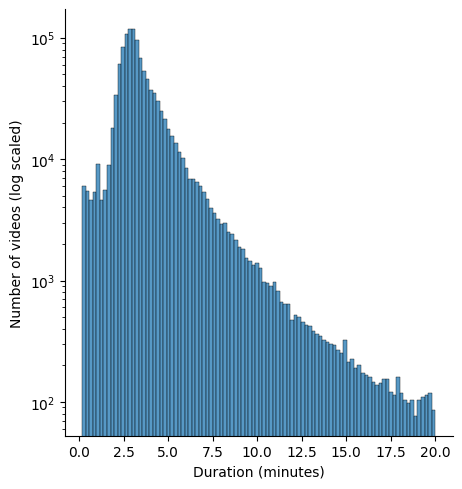

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(metadata, x="duration_mins", bins=100)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of videos (log scaled)")
plt.yscale('log')  # <-- set y-axis to log scale
plt.show()


In [5]:
def get_description_str(descriptionSnippet):
    if isinstance(descriptionSnippet, list):
        return " ".join([d["text"] for d in descriptionSnippet]).replace("\n", " ").replace("\r", " ")
    else:
        return descriptionSnippet

metadata["description"] = metadata.descriptionSnippet.apply(get_description_str)


In [6]:
from collections import Counter
from itertools import islice
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Make sure you've downloaded stopwords & tokenizer models:
# import nltk
# nltk.download('punkt')
# nltk.download('stopwords')

# Combine stopwords from multiple languages
languages = ['english', 'german', 'french', 'spanish', 'italian', 'portuguese']  # extend as needed
stop_words = set()
for lang in languages:
    stop_words.update(stopwords.words(lang))

def ngrams(tokens, n):
    return zip(*(islice(tokens, i, None) for i in range(n)))

def clean_and_tokenize(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalnum() and word not in stop_words]

def get_top_ngrams(series, n=1, top_k=20):
    all_ngrams = Counter()
    for text in series.dropna().astype(str):
        tokens = clean_and_tokenize(text)
        all_ngrams.update(ngrams(tokens, n))
    return all_ngrams.most_common(top_k)

# Assuming your dataframe is called df
for column in ['title', 'description']:
    print(f"\n==== {column.upper()} ====")
    for n in [1, 2, 3]:
        top = get_top_ngrams(metadata[column], n=n, top_k=15)  # adjust top_k as needed
        print(f"\nTop {n}-grams (stopwords removed):")
        for phrase, count in top:
            joined = " ".join(phrase) if isinstance(phrase, tuple) else phrase
            print(f"{joined}: {count}")



==== TITLE ====

Top 1-grams (stopwords removed):
live: 57129
love: 49002
cover: 47189
blues: 40447
remastered: 27554
lyrics: 23082
version: 20034
little: 17546
guitar: 16724
karaoke: 15658
baby: 15087
time: 14882
video: 14241
heart: 13260
got: 12240

Top 2-grams (stopwords removed):
karaoke version: 4570
official audio: 4162
elvis presley: 4024
guitar cover: 3866
first time: 3847
music video: 3547
guitar lesson: 3400
bob dylan: 3396
taylor swift: 3100
bass cover: 2963
remastered 2014: 2868
official video: 2676
time hearing: 2526
drum cover: 2269
acoustic cover: 2238

Top 3-grams (stopwords removed):
first time hearing: 2504
official music video: 2014
karaoke version karafun: 1223
karaoke version zoom: 1053
version zoom karaoke: 1038
nat king cole: 811
first time reaction: 761
guitar lesson tutorial: 713
creedence clearwater revival: 639
jerry lee lewis: 619
official lyric video: 585
bass cover tabs: 538
townes van zandt: 531
bob dylan cover: 448
pet shop boys: 415

==== DESCRIPTION =